# KNN 血糖预测模型

本 Notebook 使用 K-Nearest Neighbors (KNN) 算法进行血糖预测。
主要步骤包括：
1. 数据加载与预处理
2. 滑动窗口特征构建 (融合 Age 和 BMI)
3. 数据标准化
4. 模型训练
5. 评估指标计算 (MAE, RMSE, MAPE, RMSPE)
6. 结果可视化

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set scientific plotting style (referencing filter_comparison.ipynb)
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [100]:
# 加载训练集和测试集
train_path = '../../DataSplit/TrainTest/Train.csv'
test_path = '../../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print("训练集形状:", df_train.shape)
print("测试集形状:", df_test.shape)
df_train.head()

训练集形状: (83253, 5)
测试集形状: (11376, 5)


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


In [101]:
def create_dataset(data, n_past):
    """
    创建滑动窗口数据集
    
    参数:
    data:包含 'id', 'gl', 'age', 'bmi' 列的 DataFrame
    n_past: 过去的时间步数 (滑动窗口大小)
    
    返回:
    X: 特征矩阵 (n_samples, n_features)
    y: 目标向量 (n_samples,)
    """
    X, y = [], []
    
    # 按受试者分组处理，避免跨受试者构建窗口
    for subject_id, group in data.groupby('id'):
        # 获取血糖值、年龄和BMI
        gl_values = group['gl'].values
        # 假设每个受试者的 age 和 bmi 是常数，取第一行即可
        age = group['age'].iloc[0] 
        bmi = group['bmi'].iloc[0] 
        
        # 构建滑动窗口
        for i in range(n_past, len(gl_values)):
            # 过去 n_past 个时间步的血糖值
            past_gl = gl_values[i-n_past:i]
            
            # 将血糖序列与静态特征拼接
            # 特征向量: [gl_t-N, ..., gl_t-1, age, bmi]
            features = np.append(past_gl, [age, bmi])
            
            X.append(features)
            y.append(gl_values[i]) # 预测当前时间步的血糖值
            
    return np.array(X), np.array(y)

# 设定滑动窗口大小 (例如过去 12 个点，即 1 小时数据预测下一个点)
N_PAST = 12 

# 构建训练集和测试集
print("正在构建滑动窗口数据集...")
X_train, y_train = create_dataset(df_train, N_PAST)
X_test, y_test = create_dataset(df_test, N_PAST)

print(f"构建特征后的训练集形状: X={X_train.shape}, y={y_train.shape}")
print(f"构建特征后的测试集形状: X={X_test.shape}, y={y_test.shape}")

正在构建滑动窗口数据集...
构建特征后的训练集形状: X=(81357, 14), y=(81357,)
构建特征后的测试集形状: X=(9480, 14), y=(9480,)


In [102]:
# 数据标准化
# KNN 对距离敏感，必须对特征进行标准化
scaler = StandardScaler()

# 在训练集上拟合 scaler，并转换训练集
X_train_scaled = scaler.fit_transform(X_train)

# 使用训练集的 scaler 转换测试集 (避免数据泄露)
X_test_scaled = scaler.transform(X_test)

print("前5个样本的标准化特征 (部分展示):")
print(X_train_scaled[:5, :5]) # 展示前5行前5列

前5个样本的标准化特征 (部分展示):
[[-0.56481287 -0.54096664 -0.52785235 -0.52437623 -0.5294274 ]
 [-0.54063864 -0.52751744 -0.52402228 -0.5290563  -0.54150676]
 [-0.52719544 -0.52368882 -0.52870075 -0.54113174 -0.55986749]
 [-0.52336852 -0.52836552 -0.54077206 -0.55948652 -0.58339317]
 [-0.52804314 -0.5404323  -0.55912055 -0.58300457 -0.61162988]]


In [103]:
# 构建 KNN 模型
# n_neighbors 是关键超参数，这里先设为 5，实际应用中可以通过交叉验证优化
knn_model = KNeighborsRegressor(n_neighbors=5)

# 训练模型
print("开始训练 KNN 模型...")
knn_model.fit(X_train_scaled, y_train)
print("模型训练完成。")

开始训练 KNN 模型...
模型训练完成。


In [104]:
# 在测试集上进行预测
y_pred = knn_model.predict(X_test_scaled)

# 计算评价指标
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # 避免除以0的情况，虽然血糖值通常不为0
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    
    return mae, rmse, mape, rmspe

mae, rmse, mape, rmspe = calculate_metrics(y_test, y_pred)

print("-" * 30)
print("模型评估结果:")
print(f"MAE (平均绝对误差): {mae:.4f} mg/dL")
print(f"RMSE (均方根误差): {rmse:.4f} mg/dL")
print(f"MAPE (平均绝对百分比误差): {mape:.4f}%")
print(f"RMSPE (均方根百分比误差): {rmspe:.4f}%")
print("-" * 30)

------------------------------
模型评估结果:
MAE (平均绝对误差): 2.2798 mg/dL
RMSE (均方根误差): 3.2147 mg/dL
MAPE (平均绝对百分比误差): 2.1102%
RMSPE (均方根百分比误差): 2.8307%
------------------------------


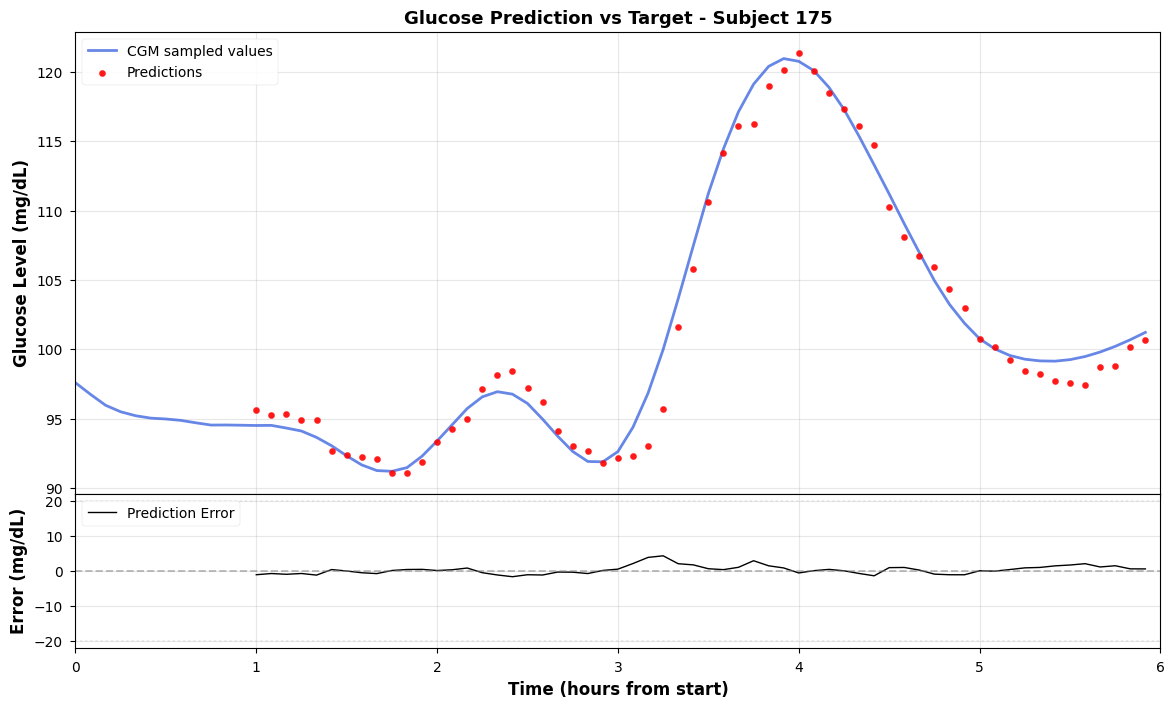

Subject 175 (MAPE 0.94%): Visualization generated.


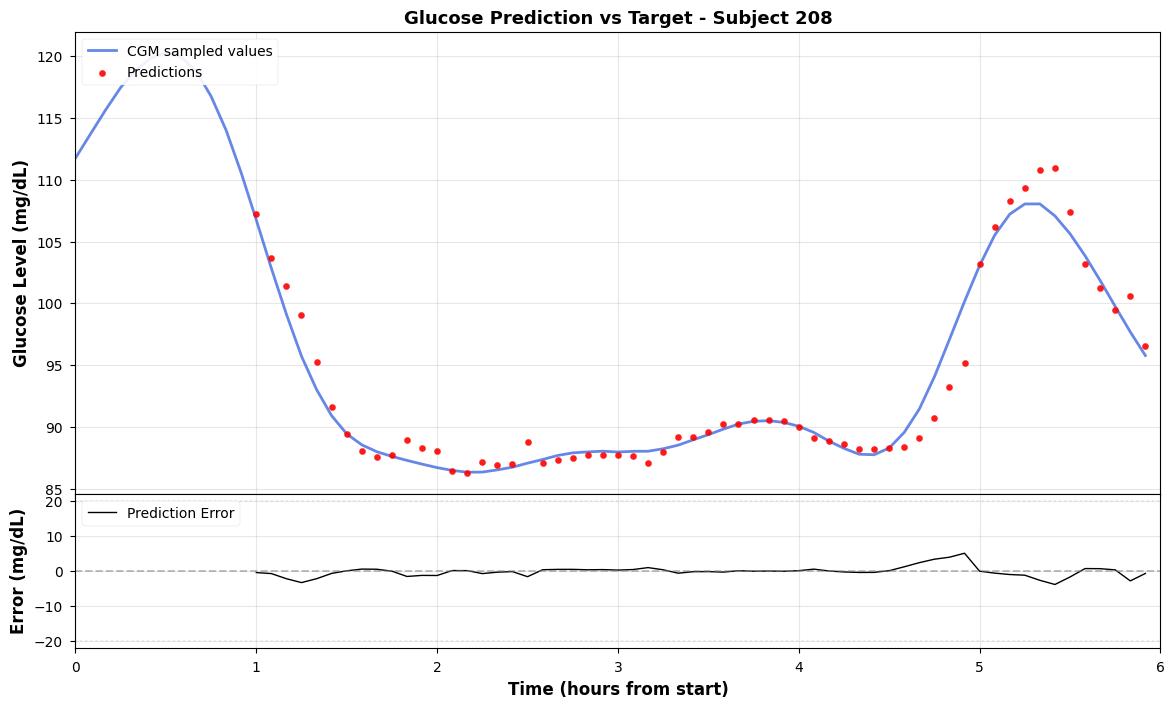

Subject 208 (MAPE 1.01%): Visualization generated.


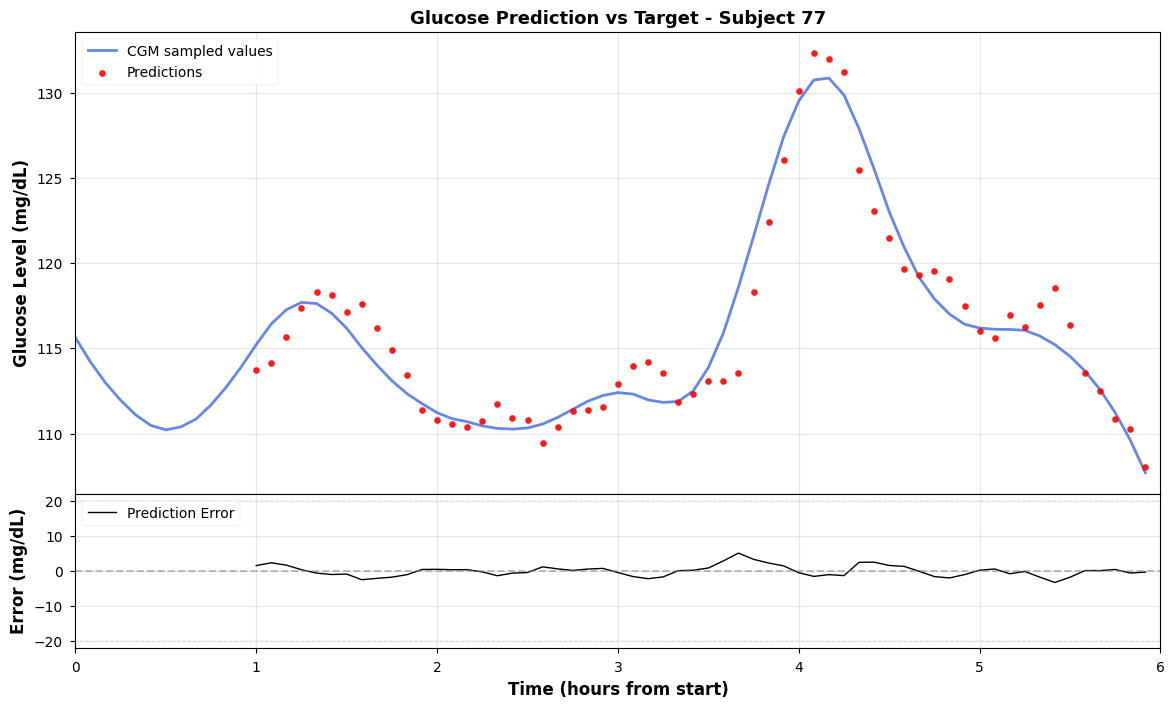

Subject 77 (MAPE 1.03%): Visualization generated.


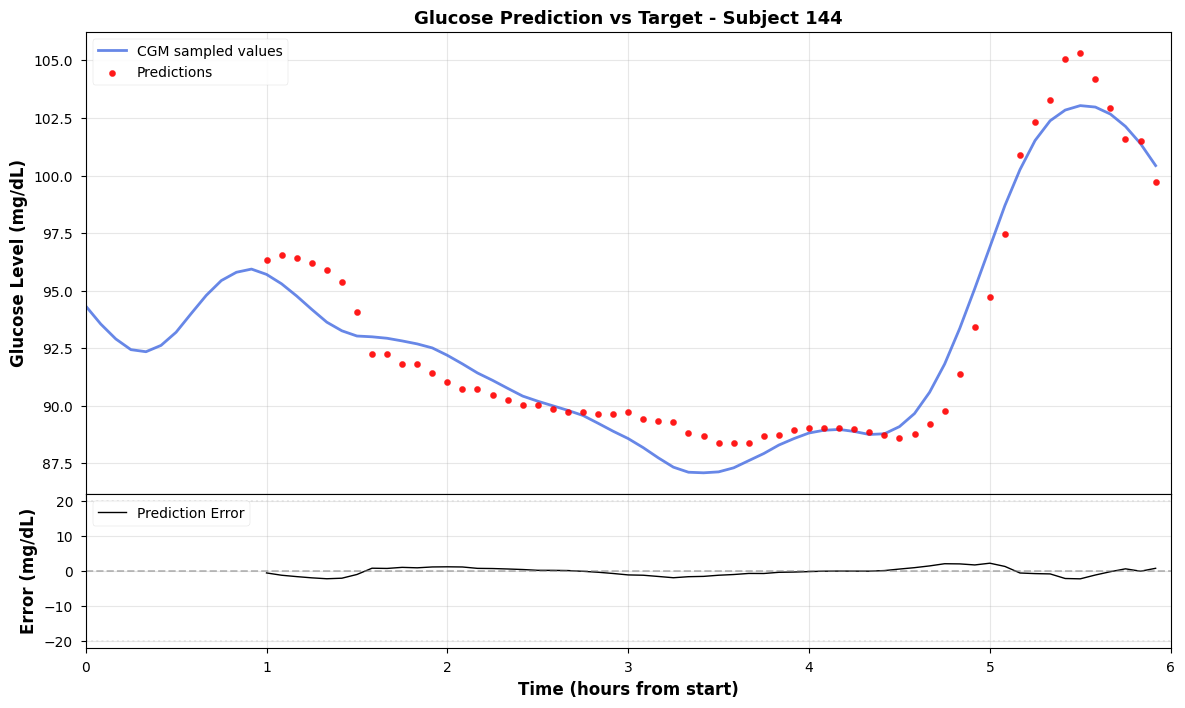

Subject 144 (MAPE 1.03%): Visualization generated.


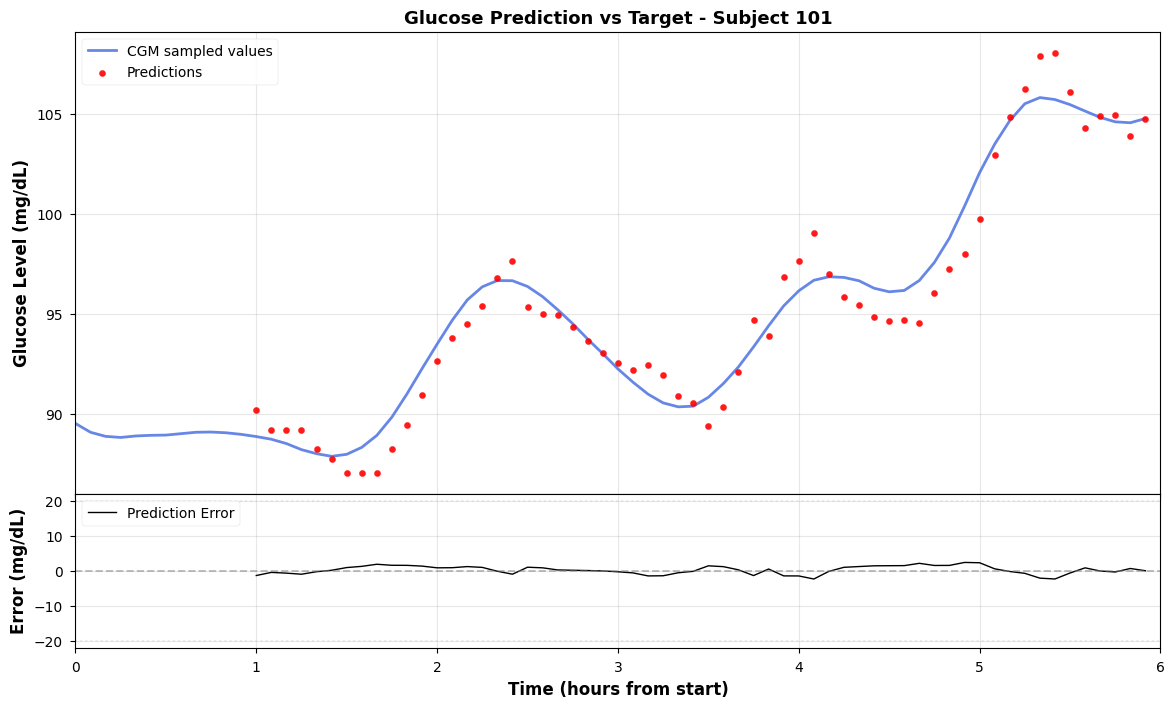

Subject 101 (MAPE 1.04%): Visualization generated.


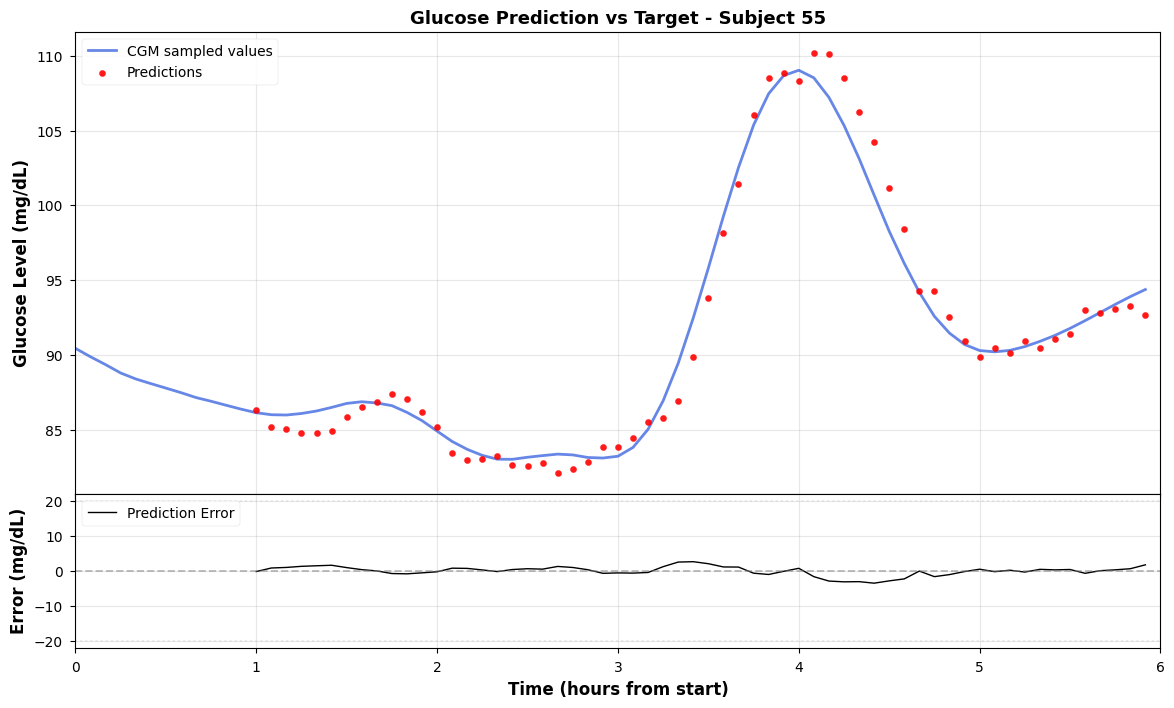

Subject 55 (MAPE 1.06%): Visualization generated.


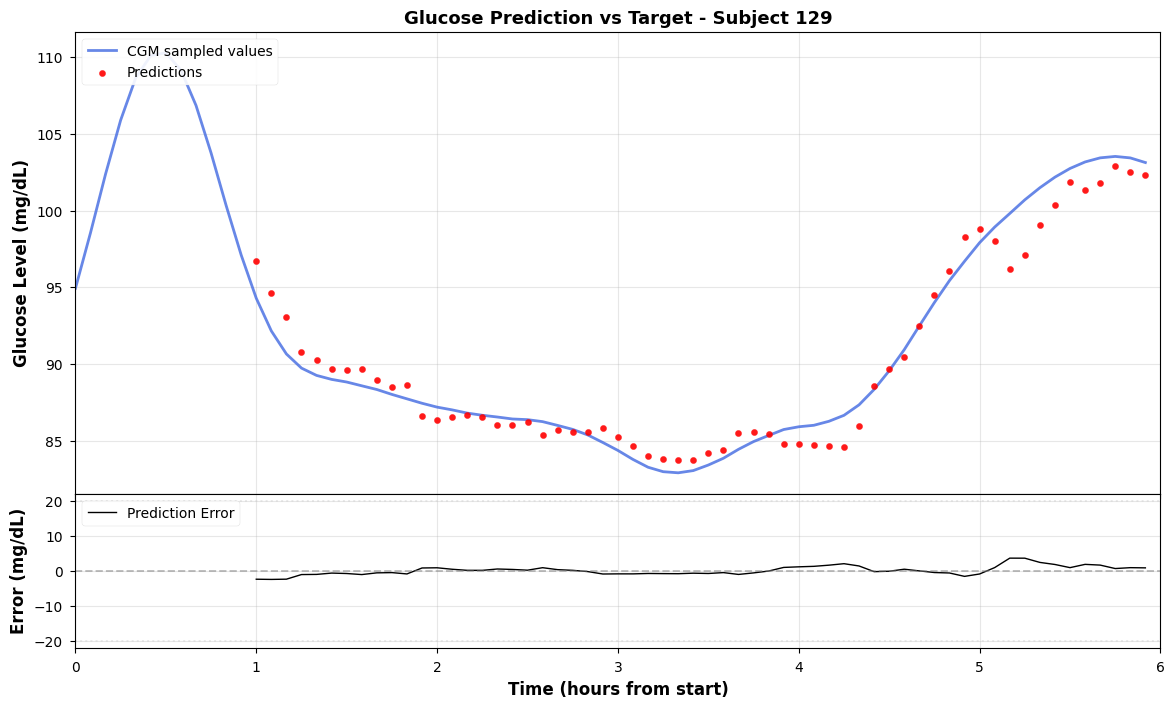

Subject 129 (MAPE 1.08%): Visualization generated.


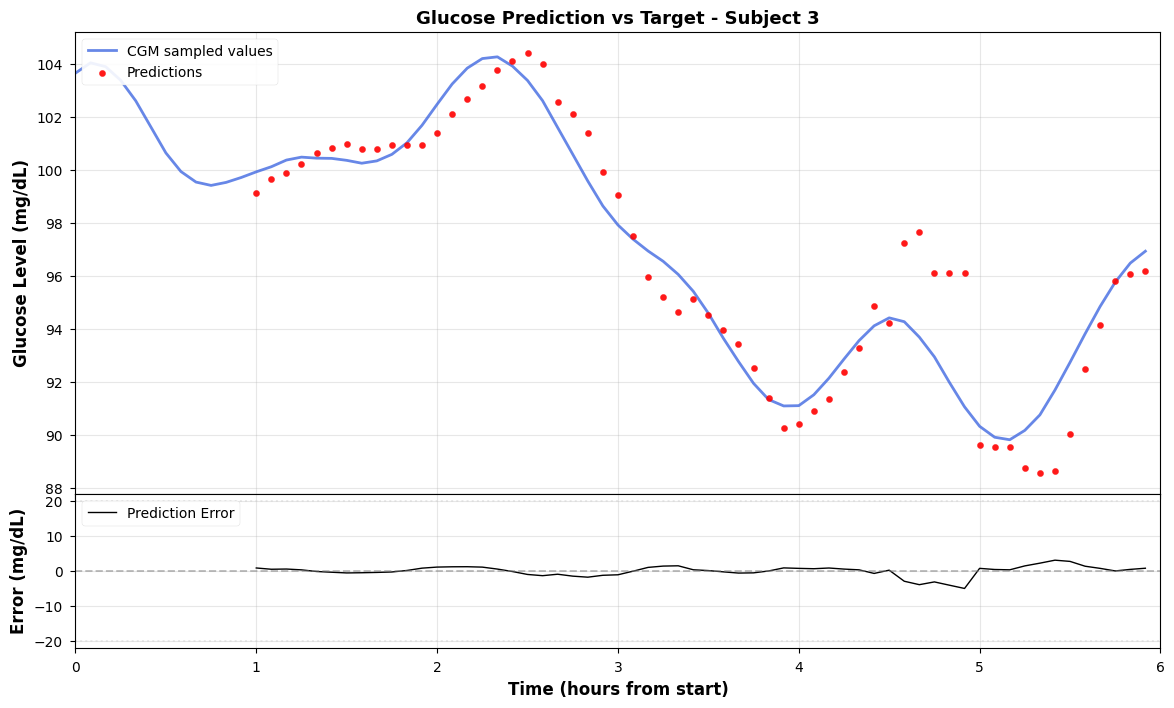

Subject 3 (MAPE 1.11%): Visualization generated.


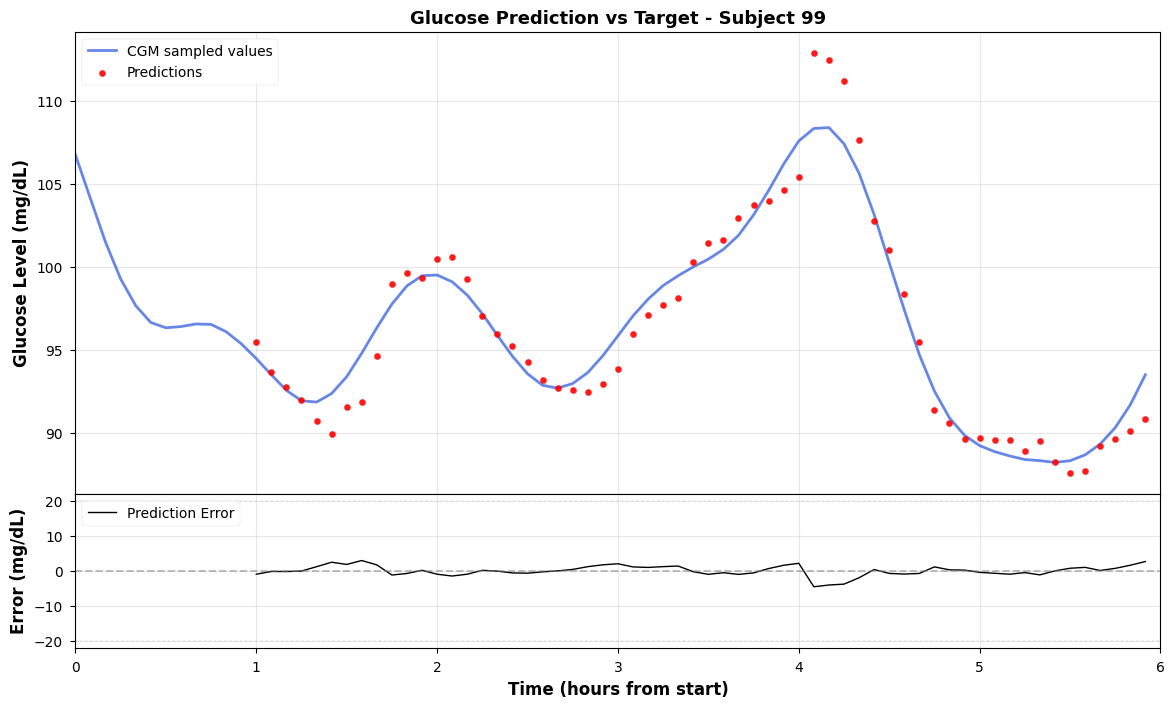

Subject 99 (MAPE 1.12%): Visualization generated.


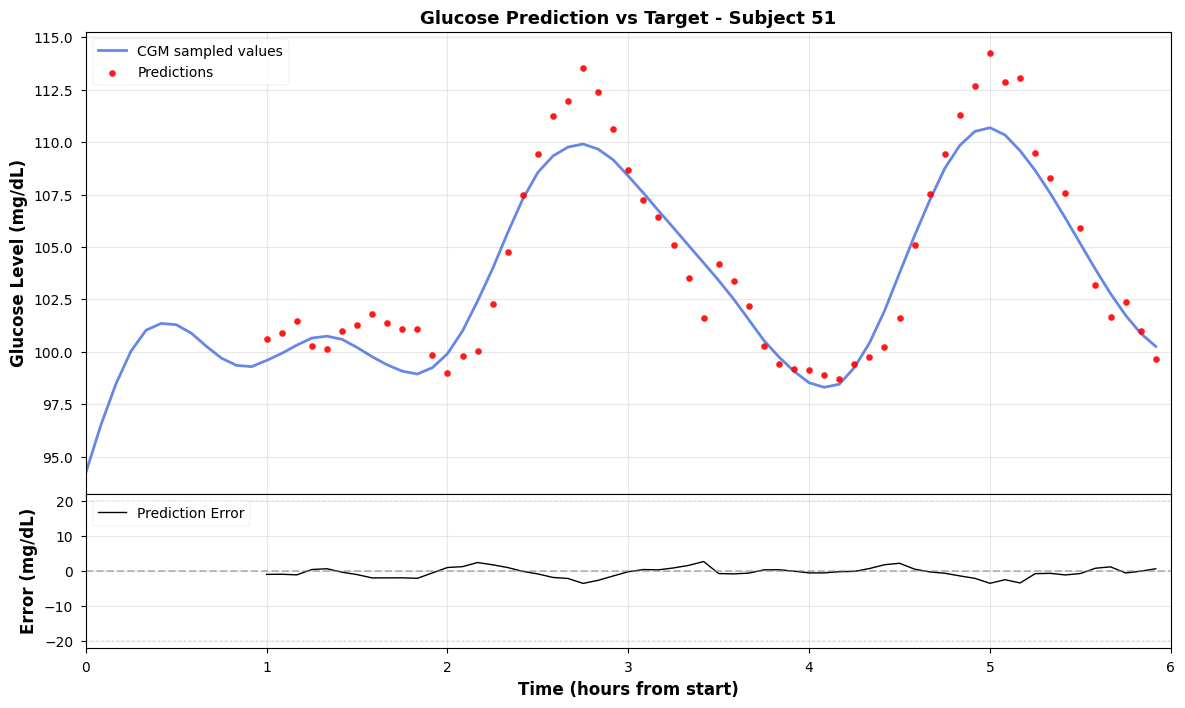

Subject 51 (MAPE 1.13%): Visualization generated.


In [105]:
import matplotlib.dates as mdates

# 获取测试集中所有受试者的 ID（已排序）
subject_ids = sorted(df_test['id'].unique())

# 先计算每个受试者的 MAPE，用于挑选前 10 名
subject_stats = []
current_idx = 0
for subject_id in subject_ids:
    # 提取并按时间排序该受试者的数据
    subject_data = df_test[df_test['id'] == subject_id].copy().sort_values('time')

    # 计算可用样本数（总行数减去窗口长度）
    n_samples = len(subject_data) - N_PAST
    if n_samples <= 0:
        continue

    # 从拼接数组中切片得到该受试者的真实值和预测值
    y_true_subj = y_test[current_idx : current_idx + n_samples]
    y_pred_subj = y_pred[current_idx : current_idx + n_samples]
    current_idx += n_samples

    # 计算该受试者的 MAPE（避开 0）
    mask = y_true_subj != 0
    if mask.any():
        mape_subj = np.mean(np.abs((y_true_subj[mask] - y_pred_subj[mask]) / y_true_subj[mask])) * 100
    else:
        mape_subj = np.nan

    subject_stats.append({
        'id': subject_id,
        'mape': mape_subj,
        'data': subject_data,
        'y_true': y_true_subj,
        'y_pred': y_pred_subj,
    })

# 按 MAPE 升序取前 10 个受试者
subject_stats = [s for s in subject_stats if not np.isnan(s['mape'])]
subject_stats = sorted(subject_stats, key=lambda x: x['mape'])[:10]

# 绘图（仅展示 MAPE 最小的 10 个受试者）
for stat in subject_stats:
    subject_id = stat['id']
    subject_data = stat['data']
    y_true_subj = stat['y_true']
    y_pred_subj = stat['y_pred']
    error = y_true_subj - y_pred_subj

    # 构造 0-6 小时的相对时间轴（5 分钟采样 → 每步 5/60 小时）
    full_hours = np.arange(len(subject_data)) * (5 / 60)
    pred_hours = full_hours[N_PAST:]

    # 全部真实值（用于顶图连续曲线）
    y_true_full = subject_data['gl'].values

    # 绘图：上下两层共享 X 轴、无间隙
    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},
    )

    # 顶图：真实曲线 + 预测散点
    ax1.plot(full_hours, y_true_full, label='CGM sampled values', color='royalblue', linewidth=2, alpha=0.8)
    ax1.scatter(pred_hours, y_pred_subj, label='Predictions', color='red', s=20, alpha=0.9, zorder=5)
    ax1.set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    ax1.set_title(f'Glucose Prediction vs Target - Subject {subject_id}', fontweight='bold')
    ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax1.grid(True, alpha=0.3)

    # 底图：误差序列
    ax2.plot(pred_hours, error, label='Prediction Error', color='black', linewidth=1)
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.axhline(y=-20, color='lightgray', linestyle=':', alpha=0.5)
    ax2.set_ylabel('Error (mg/dL)', fontweight='bold')
    ax2.set_xlabel('Time (hours from start)', fontweight='bold')
    ax2.legend(loc='upper left', frameon=True, framealpha=0.9)
    ax2.grid(True, alpha=0.3)

    # X 轴：每小时一个刻度，固定 0-6 小时
    ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}'))
    ax2.set_xlim(0, 6)

    plt.show()
    print(f"Subject {subject_id} (MAPE {stat['mape']:.2f}%): Visualization generated.")
